# So sánh kiến trúc — Sparse Alpha Interpretability

Notebook **phụ** (không phải bản chính cho báo cáo). Chạy 3 thí nghiệm để so sánh:

| Exp | Model | Mục đích |
|-----|-------|----------|
| **A** | MLP 3 hidden + L1 (λ=1e-4) | Config cũ — lịch sử cho ρ=0.803, IC=0.047 |
| **B** | MLP 4 hidden + L1 (λ=1e-4) | Config hiện tại — IC=0.065, ρ=0.370 |
| **C** | TabNet (4 hyperparameter combos) | Sparse feature selection built-in (Arik & Pfister 2019) |

**Mục tiêu**: xác định trade-off giữa IC (predictive) và ρ (Weight–SHAP agreement) trên cùng data, cùng split.

Notebook chính `sparse_alpha.ipynb` **giữ nguyên**, không bị ảnh hưởng bởi thí nghiệm này.

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import pandas_ta as ta
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr
import shap

from pytorch_tabnet.tab_model import TabNetRegressor

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42); np.random.seed(42)

DATA_DIR  = r'D:\S2_Year4\Quantitative Trading\Project\data'
VN30 = ['ACB','BCM','BID','BVH','CTG','FPT','GAS','GVR','HDB','HPG',
        'MBB','MSN','MWG','NVL','PDR','PLX','POW','SAB','SSI','STB',
        'TCB','TPB','VCB','VHM','VIB','VIC','VJC','VNM','VPB','VRE']

FORWARD_DAYS = 5
TRAIN_END    = '2020-12-31'
VAL_END      = '2022-06-30'
L1_LAMBDA    = 1e-4
DROPOUT      = 0.1
BATCH_SIZE   = 256
EPOCHS       = 200
PATIENCE     = 20

print(f'device: {device}')

device: cpu


## 1. Load data + Feature engineering + Split (giống `sparse_alpha.ipynb`)

In [2]:
def load_vn30(data_dir, symbols):
    dfs = []
    for sym in symbols:
        fp = os.path.join(data_dir, f'{sym}.csv')
        if os.path.exists(fp): dfs.append(pd.read_csv(fp))
    df = pd.concat(dfs, ignore_index=True)
    df['TradingDate'] = pd.to_datetime(df['TradingDate'], format='%d/%m/%Y')
    df = df.drop(columns=['Time','Value'], errors='ignore')
    return df.sort_values(['Symbol','TradingDate']).reset_index(drop=True)

def create_features(g):
    g = g.copy().reset_index(drop=True)
    for col in ['Open','High','Low','Close','Volume']: g[col] = g[col].astype(float)
    c, h, l, v, o = g['Close'], g['High'], g['Low'], g['Volume'], g['Open']
    for p in [1,3,5,10,20,60]: g[f'return_{p}d'] = c.pct_change(p)
    for p in [5,10,20]:        g[f'roc_{p}']     = ta.roc(c, length=p)
    for p in [5,10,20,50]:     g[f'close_to_sma_{p}'] = c / ta.sma(c, length=p)
    macd = ta.macd(c, 12, 26, 9)
    if macd is not None:
        g['macd'], g['macd_hist'], g['macd_signal'] = macd.iloc[:,0], macd.iloc[:,1], macd.iloc[:,2]
    g['rsi_14'] = ta.rsi(c, 14); g['rsi_7'] = ta.rsi(c, 7)
    stoch = ta.stoch(h, l, c, 14, 3)
    if stoch is not None: g['stoch_k'], g['stoch_d'] = stoch.iloc[:,0], stoch.iloc[:,1]
    g['willr_14'] = ta.willr(h, l, c, 14); g['cci_20'] = ta.cci(h, l, c, 20)
    g['atr_ratio'] = ta.atr(h, l, c, 14) / c
    bb = ta.bbands(c, 20, 2)
    if bb is not None:
        g['bb_pct_b'] = (c - bb.iloc[:,0]) / (bb.iloc[:,2] - bb.iloc[:,0])
        g['bb_width'] = (bb.iloc[:,2] - bb.iloc[:,0]) / bb.iloc[:,1]
    g['std_ratio'] = c.rolling(20).std() / c
    v5, v20 = ta.sma(v, 5), ta.sma(v, 20)
    g['vol_ratio_5_20'] = v5 / v20
    g['vol_change_1d'] = v.pct_change(1); g['vol_change_5d'] = v.pct_change(5)
    g['obv_norm'] = ta.obv(c, v) / v20
    g['hl_ratio']     = (h - l) / c
    g['co_ratio']     = (c - o) / o
    g['gap']          = (o - c.shift(1)) / c.shift(1)
    g['upper_shadow'] = (h - np.maximum(c, o)) / c
    g['lower_shadow'] = (np.minimum(c, o) - l) / c
    return g

df = load_vn30(DATA_DIR, VN30)
df_feat = df.groupby('Symbol', group_keys=False).apply(create_features)
FEATURE_COLS = [c for c in df_feat.columns
                if c not in ['Symbol','TradingDate','Open','High','Low','Close','Volume']]

df_feat['target'] = df_feat.groupby('Symbol')['Close'].transform(
    lambda x: x.shift(-FORWARD_DAYS) / x - 1)
df_clean = df_feat.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

df_train = df_clean[df_clean['TradingDate'] <= TRAIN_END]
df_val   = df_clean[(df_clean['TradingDate'] > TRAIN_END) & (df_clean['TradingDate'] <= VAL_END)]
df_test  = df_clean[df_clean['TradingDate'] > VAL_END]

X_train, y_train = df_train[FEATURE_COLS].values.astype(np.float32), df_train['target'].values.astype(np.float32)
X_val,   y_val   = df_val[FEATURE_COLS].values.astype(np.float32),   df_val['target'].values.astype(np.float32)
X_test,  y_test  = df_test[FEATURE_COLS].values.astype(np.float32),  df_test['target'].values.astype(np.float32)

scaler = StandardScaler()
X_train = np.nan_to_num(scaler.fit_transform(X_train)).astype(np.float32)
X_val   = np.nan_to_num(scaler.transform(X_val)).astype(np.float32)
X_test  = np.nan_to_num(scaler.transform(X_test)).astype(np.float32)

input_dim = len(FEATURE_COLS)
print(f'features: {input_dim} | Train {X_train.shape} | Val {X_val.shape} | Test {X_test.shape}')

features: 35 | Train (42024, 35) | Val (11490, 35) | Test (7620, 35)


## 2. MLP shared utilities (giống `sparse_alpha.ipynb`)

In [3]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout=DROPOUT):
        super().__init__()
        layers, prev = [], input_dim
        for hd in hidden_dims:
            layers += [nn.Linear(prev, hd), nn.ReLU(), nn.BatchNorm1d(hd)]
            if dropout > 0: layers.append(nn.Dropout(dropout))
            prev = hd
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)
    def l1_loss(self): return sum(torch.sum(torch.abs(p)) for p in self.parameters())
    def sparsity(self, threshold=1e-4):
        total = sum(p.numel() for p in self.parameters())
        zeros = sum((p.abs() < threshold).sum().item() for p in self.parameters())
        return zeros / total

def train_mlp(model, l1_lambda, name):
    Xtr_t = torch.FloatTensor(X_train).to(device)
    ytr_t = torch.FloatTensor(y_train).reshape(-1, 1).to(device)
    Xv_t  = torch.FloatTensor(X_val).to(device)
    yv_t  = torch.FloatTensor(y_val).reshape(-1, 1).to(device)
    loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=BATCH_SIZE, shuffle=True)

    opt = optim.Adam(model.parameters(), lr=1e-3); crit = nn.MSELoss()
    best, best_state, no_imp = float('inf'), None, 0
    print(f'\n🚀 {name} | λ={l1_lambda}')
    for ep in range(EPOCHS):
        model.train()
        for Xb, yb in loader:
            opt.zero_grad()
            mse = crit(model(Xb), yb)
            loss = mse + l1_lambda * model.l1_loss() if l1_lambda > 0 else mse
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad(): v = crit(model(Xv_t), yv_t).item()
        if v < best:
            best = v; best_state = {k: t.clone() for k, t in model.state_dict().items()}; no_imp = 0
        else: no_imp += 1
        if no_imp >= PATIENCE:
            print(f'  ⏹️ early stop @ ep {ep+1} | best val {best:.5f}'); break
    model.load_state_dict(best_state)
    return model

def evaluate_mlp(model, name):
    model.eval()
    Xte_t = torch.FloatTensor(X_test).to(device)
    with torch.no_grad(): yp = model(Xte_t).cpu().numpy().flatten()
    mse = mean_squared_error(y_test, yp)
    ic = float(np.corrcoef(y_test, yp)[0, 1])
    sp = model.sparsity()
    return {'name': name, 'mse': mse, 'rmse': np.sqrt(mse), 'ic': ic, 'sparsity': sp}

def mlp_weight_importance(model):
    W = next(m.weight.data.cpu().numpy() for m in model.net if isinstance(m, nn.Linear))
    return np.sum(np.abs(W), axis=0)

def shap_importance(model, X_train_np, X_test_np, n_bg=200, n_explain=500):
    np.random.seed(42)
    bg_idx = np.random.choice(len(X_train_np), n_bg, replace=False)
    te_idx = np.random.choice(len(X_test_np), n_explain, replace=False)
    bg = torch.FloatTensor(X_train_np[bg_idx]).to(device)
    te = torch.FloatTensor(X_test_np[te_idx]).to(device)
    model.eval()
    try:
        ex = shap.DeepExplainer(model, bg)
        sv = ex.shap_values(te, check_additivity=False)
    except Exception:
        ex = shap.GradientExplainer(model, bg)
        sv = ex.shap_values(te)
    if isinstance(sv, list): sv = sv[0]
    sv = np.asarray(sv).reshape(te.shape[0], -1)
    return np.mean(np.abs(sv), axis=0)

def compute_rho(weight_imp, shap_imp):
    wr = pd.Series(weight_imp).rank(ascending=False).values
    sr = pd.Series(shap_imp).rank(ascending=False).values
    rho, _ = spearmanr(wr, sr)
    return rho

print('utilities ready')

utilities ready


## 3. Experiment A — MLP 3 hidden layers

In [4]:
torch.manual_seed(42); np.random.seed(42)
model_3h = MLP(input_dim, hidden_dims=[128, 64, 32]).to(device)
model_3h = train_mlp(model_3h, L1_LAMBDA, 'MLP-3h Sparse')

res_3h = evaluate_mlp(model_3h, 'MLP-3h')
wimp_3h = mlp_weight_importance(model_3h)
simp_3h = shap_importance(model_3h, X_train, X_test)
rho_3h = compute_rho(wimp_3h, simp_3h)

res_3h['rho'] = rho_3h
print(f"\n📊 MLP-3h | MSE={res_3h['mse']:.5f} IC={res_3h['ic']:.4f} "
      f"Sparsity={res_3h['sparsity']:.1%} ρ={rho_3h:.3f}")


🚀 MLP-3h Sparse | λ=0.0001
  ⏹️ early stop @ ep 35 | best val 0.00339

📊 MLP-3h | MSE=0.00316 IC=0.0379 Sparsity=65.0% ρ=0.464


## 4. Experiment B — MLP 4 hidden layers (current config)

In [5]:
torch.manual_seed(42); np.random.seed(42)
model_4h = MLP(input_dim, hidden_dims=[256, 128, 64, 32]).to(device)
model_4h = train_mlp(model_4h, L1_LAMBDA, 'MLP-4h Sparse')

res_4h = evaluate_mlp(model_4h, 'MLP-4h')
wimp_4h = mlp_weight_importance(model_4h)
simp_4h = shap_importance(model_4h, X_train, X_test)
rho_4h = compute_rho(wimp_4h, simp_4h)

res_4h['rho'] = rho_4h
print(f"\n📊 MLP-4h | MSE={res_4h['mse']:.5f} IC={res_4h['ic']:.4f} "
      f"Sparsity={res_4h['sparsity']:.1%} ρ={rho_4h:.3f}")


🚀 MLP-4h Sparse | λ=0.0001
  ⏹️ early stop @ ep 36 | best val 0.00340

📊 MLP-4h | MSE=0.00314 IC=0.0314 Sparsity=90.7% ρ=0.434


## 5. Experiment C — TabNet (4 hyperparameter combos)

TabNet (Arik & Pfister, 2019, AAAI) có **sparse feature selection built-in**: mỗi decision step
dùng sparsemax mask để chọn subset features khác nhau. `feature_importances_` của TabNet =
tổng usage của mỗi feature qua tất cả decision steps.

Tune nhẹ 4 combos để tìm config tốt nhất theo **val MSE**:

| Combo | n_d (decision dim) | n_steps | λ_sparse |
|-------|--------------------|---------|----------|
| C1 | 8  | 3 | 1e-3 (default) |
| C2 | 8  | 3 | 1e-2 (more sparse) |
| C3 | 16 | 4 | 1e-3 (wider, deeper) |
| C4 | 8  | 5 | 1e-3 (more steps) |

In [6]:
y_train_2d = y_train.reshape(-1, 1)
y_val_2d   = y_val.reshape(-1, 1)

tabnet_configs = [
    {'name': 'C1', 'n_d': 8,  'n_a': 8,  'n_steps': 3, 'lambda_sparse': 1e-3},
    {'name': 'C2', 'n_d': 8,  'n_a': 8,  'n_steps': 3, 'lambda_sparse': 1e-2},
    {'name': 'C3', 'n_d': 16, 'n_a': 16, 'n_steps': 4, 'lambda_sparse': 1e-3},
    {'name': 'C4', 'n_d': 8,  'n_a': 8,  'n_steps': 5, 'lambda_sparse': 1e-3},
]

tabnet_results = []
for cfg in tabnet_configs:
    print(f"\n🚀 TabNet {cfg['name']} | n_d={cfg['n_d']} n_steps={cfg['n_steps']} λs={cfg['lambda_sparse']}")
    torch.manual_seed(42); np.random.seed(42)
    tn = TabNetRegressor(
        n_d=cfg['n_d'], n_a=cfg['n_a'], n_steps=cfg['n_steps'],
        lambda_sparse=cfg['lambda_sparse'],
        optimizer_fn=torch.optim.Adam,
        optimizer_params={'lr': 1e-3},
        scheduler_params={'step_size': 30, 'gamma': 0.9},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        seed=42, verbose=0, device_name=str(device),
    )
    tn.fit(
        X_train, y_train_2d,
        eval_set=[(X_val, y_val_2d)],
        max_epochs=EPOCHS, patience=PATIENCE,
        batch_size=BATCH_SIZE, virtual_batch_size=64,
        eval_metric=['mse'],
    )
    val_mse = tn.history['val_0_mse'][-1]
    yp = tn.predict(X_test).flatten()
    test_mse = mean_squared_error(y_test, yp)
    test_ic = float(np.corrcoef(y_test, yp)[0, 1])
    print(f"  val MSE={val_mse:.5f} | test MSE={test_mse:.5f} IC={test_ic:.4f}")
    tabnet_results.append({'cfg': cfg, 'model': tn, 'val_mse': val_mse,
                            'test_mse': test_mse, 'test_ic': test_ic, 'y_pred': yp})

# Chọn best theo val MSE (KHÔNG chọn theo test — tránh leak)
best_tn = min(tabnet_results, key=lambda r: r['val_mse'])
print(f"\n🏆 Best TabNet (theo val MSE): {best_tn['cfg']['name']} | val={best_tn['val_mse']:.5f}")


🚀 TabNet C1 | n_d=8 n_steps=3 λs=0.001

Early stopping occurred at epoch 39 with best_epoch = 19 and best_val_0_mse = 0.0034000000450760126
  val MSE=0.00341 | test MSE=0.00316 IC=-0.0517

🚀 TabNet C2 | n_d=8 n_steps=3 λs=0.01

Early stopping occurred at epoch 34 with best_epoch = 14 and best_val_0_mse = 0.0034000000450760126
  val MSE=0.00341 | test MSE=0.00317 IC=-0.0356

🚀 TabNet C3 | n_d=16 n_steps=4 λs=0.001

Early stopping occurred at epoch 65 with best_epoch = 45 and best_val_0_mse = 0.0034000000450760126
  val MSE=0.00342 | test MSE=0.00314 IC=0.0328

🚀 TabNet C4 | n_d=8 n_steps=5 λs=0.001

Early stopping occurred at epoch 45 with best_epoch = 25 and best_val_0_mse = 0.0034000000450760126
  val MSE=0.00341 | test MSE=0.00315 IC=-0.0263

🏆 Best TabNet (theo val MSE): C2 | val=0.00341


In [7]:
tn_best_model = best_tn['model']

# Sparsity proxy cho TabNet: % features có importance ≈ 0
tn_imp_global = tn_best_model.feature_importances_
tn_sparsity = float(np.mean(tn_imp_global < 1e-4))

# SHAP bằng GradientExplainer (TabNet DeepExplainer không support)
np.random.seed(42)
bg_idx = np.random.choice(len(X_train), 200, replace=False)
te_idx = np.random.choice(len(X_test), 500, replace=False)

class TabNetWrapper(nn.Module):
    def __init__(self, tn): super().__init__(); self.tn = tn.network
    def forward(self, x): return self.tn(x)[0]

wrapper = TabNetWrapper(tn_best_model).to(device); wrapper.eval()
bg = torch.FloatTensor(X_train[bg_idx]).to(device)
te = torch.FloatTensor(X_test[te_idx]).to(device)
ex = shap.GradientExplainer(wrapper, bg)
sv = ex.shap_values(te)
if isinstance(sv, list): sv = sv[0]
sv = np.asarray(sv).reshape(te.shape[0], -1)
tn_simp = np.mean(np.abs(sv), axis=0)

# ρ: built-in importance vs SHAP
tn_rho = compute_rho(tn_imp_global, tn_simp)

res_tn = {
    'name': f"TabNet-{best_tn['cfg']['name']}",
    'mse': best_tn['test_mse'],
    'rmse': np.sqrt(best_tn['test_mse']),
    'ic': best_tn['test_ic'],
    'sparsity': tn_sparsity,
    'rho': tn_rho,
}

print(f"\n📊 {res_tn['name']} | MSE={res_tn['mse']:.5f} IC={res_tn['ic']:.4f} "
      f"Sparsity={res_tn['sparsity']:.1%} ρ={tn_rho:.3f}")


📊 TabNet-C2 | MSE=0.00317 IC=-0.0356 Sparsity=0.0% ρ=0.359


## 6. So sánh tổng hợp

    Model    MSE   RMSE      IC  Sparsity  Spearman ρ
   MLP-3h 0.0032 0.0562  0.0379    0.6504      0.4636
   MLP-4h 0.0031 0.0560  0.0314    0.9074      0.4342
TabNet-C2 0.0032 0.0563 -0.0356    0.0000      0.3591


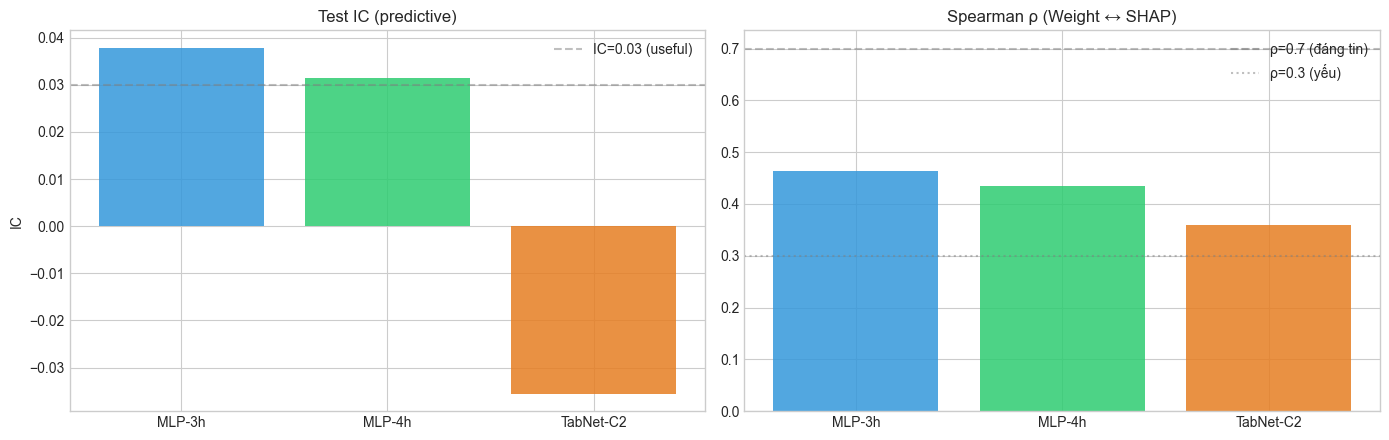

In [8]:
summary = pd.DataFrame([res_3h, res_4h, res_tn])[['name','mse','rmse','ic','sparsity','rho']]
summary.columns = ['Model','MSE','RMSE','IC','Sparsity','Spearman ρ']
print(summary.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
models = summary['Model'].values
ax = axes[0]
ax.bar(models, summary['IC'], color=['#3498DB','#2ECC71','#E67E22'], alpha=.85)
ax.axhline(0.03, ls='--', c='gray', alpha=.5, label='IC=0.03 (useful)')
ax.set_title('Test IC (predictive)'); ax.set_ylabel('IC'); ax.legend()
ax = axes[1]
ax.bar(models, summary['Spearman ρ'], color=['#3498DB','#2ECC71','#E67E22'], alpha=.85)
ax.axhline(0.7, ls='--', c='gray', alpha=.5, label='ρ=0.7 (đáng tin)')
ax.axhline(0.3, ls=':',  c='gray', alpha=.5, label='ρ=0.3 (yếu)')
ax.set_title('Spearman ρ (Weight ↔ SHAP)'); ax.legend()
plt.tight_layout()
plt.savefig('experiments_compare.png', dpi=120, bbox_inches='tight')
plt.show()